# 06. Трёхслойный MLP

## Архитектура

Три скрытых `Dense` с `relu` и `Dropout` между ними, затем выход `softmax`. По сравнению с 05-ым ноутбуком у модели **больше ёмкости**; при том же `EarlyStopping` выше риск переобучения при слишком длинных или «жирных» слоях.

In [1]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
import seaborn as sns
from helpers import load_xy_from_processed, classification_metrics_dict, print_report, append_metrics_store, PLOT_DIR, CLASS_NAMES, RANDOM_STATE

2026-04-24 22:48:36.309859: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 22:48:36.309900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 22:48:36.310989: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test, _ = load_xy_from_processed()
n_classes = len(CLASS_NAMES)

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax'),
])

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1152      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 4)                 132       
                                                                 
Total params: 11620 (45.39 KB)
Trainable params: 11620 (

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss')
]

h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=120, batch_size=64, callbacks=cb, verbose=1)

Epoch 1/120
88/88 [==============================] - 1s 2ms/step - loss: 0.8106 - accuracy: 0.6177 - val_loss: 0.4815 - val_accuracy: 0.6992
Epoch 2/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4734 - accuracy: 0.7120 - val_loss: 0.4314 - val_accuracy: 0.7308
Epoch 3/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4482 - accuracy: 0.7259 - val_loss: 0.4204 - val_accuracy: 0.7242
Epoch 4/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4300 - accuracy: 0.7216 - val_loss: 0.4204 - val_accuracy: 0.7258
Epoch 5/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4151 - accuracy: 0.7300 - val_loss: 0.4064 - val_accuracy: 0.7300
Epoch 6/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4129 - accuracy: 0.7257 - val_loss: 0.3946 - val_accuracy: 0.7342
Epoch 7/120
88/88 [==============================] - 0s 1ms/step - loss: 0.4044 - accuracy: 0.7286 - val_loss: 0.3974 - val_accuracy: 0.7342
Epoch 8/120
8

## Сравнение с однослойной сетью

05 — проще и быстрее; 06 — потенциально **точнее** на сложных границ, но сильнее зависит от регуляризации (dropout, остановка по val).

In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
m = classification_metrics_dict(y_test, y_pred)
print(m)
print_report(y_test, y_pred)

{'accuracy': 0.735, 'precision_macro': 0.7350909230441864, 'recall_macro': 0.735, 'f1_macro': 0.7349532695090277, 'precision_micro': 0.735, 'recall_micro': 0.735, 'f1_micro': 0.735}
              precision    recall  f1-score   support

    OPEN_SEA       0.98      1.00      0.99       300
 COASTAL_SEA       0.48      0.49      0.49       300
  NEAR_COAST       0.48      0.47      0.47       300
   COASTLINE       1.00      0.98      0.99       300

    accuracy                           0.73      1200
   macro avg       0.74      0.73      0.73      1200
weighted avg       0.74      0.73      0.73      1200



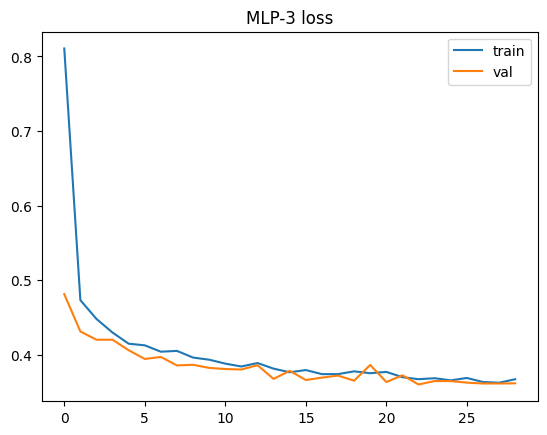

In [8]:
append_metrics_store('mlp_3hidden', m)
plt.figure()
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')
plt.legend()
plt.title('MLP-3 loss')
plt.savefig(PLOT_DIR / 'mlp3_loss.png', dpi=150)
plt.show()
plt.close()

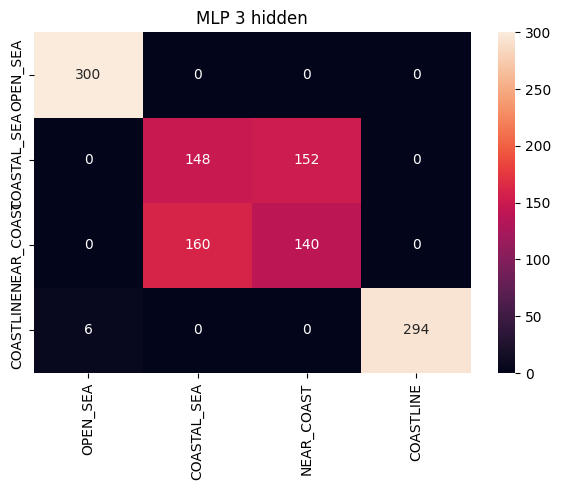

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MLP 3 hidden')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_mlp3.png', dpi=150)
plt.show()
plt.close()
